# H1 -- Cloud data access: a reusable `get_imagery(aoi, date_range, sensor)`

H0 picked one hand-selected, already-nearly-cloud-free Sentinel-2 scene. That
doesn't generalize -- Bangladesh's monsoon season often has **no** single
low-cloud scene available at all. This phase builds
[`src/imagery.get_imagery()`](../src/imagery.py): search a date range instead of
a single date, mask clouds per-pixel using the Sentinel-2 Scene Classification
Layer (SCL), and take the per-pixel median across whatever clear observations
exist -- so **any** AOI/season returns a usable composite, not just the lucky
cases H0 covered.

**Done when** (per [`PLAN.md`](../PLAN.md)): one call returns an analysis-ready
multi-band array for any AOI/season, with a monsoon vs. dry-season example for
Dhaka. Both below are the same function call, same AOI, different `date_range`.

In [1]:
import sys
sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import numpy as np

from src.imagery import get_imagery

# Same small Dhaka tile H0 used, so the two phases' outputs are directly comparable.
AOI = (90.36, 23.72, 90.44, 23.80)


## Dry season (Jan-Feb) -- the easy case

`cloud_cover_max=60` is generous on purpose: it's the composite's own cloud
masking, not a strict per-scene filter, that's actually doing the work.

In [2]:
dry_composite, dry_meta = get_imagery(AOI, '2026-01-01/2026-02-28', sensor='sentinel-2', cloud_cover_max=60, max_scenes=3)
print(dry_meta)
print('nan fraction:', float(np.isnan(dry_composite.values).mean()))


{'sensor': 'sentinel-2', 'source': 'planetary_computer', 'date_range': '2026-01-01/2026-02-28', 'n_scenes_used': 3, 'item_ids': ['S2C_MSIL2A_20260214T042901_R133_T46QBM_20260214T080510', 'S2A_MSIL2A_20260209T043901_R133_T46QBM_20260209T091708', 'S2C_MSIL2A_20260214T042901_R133_T45QZG_20260214T080510'], 'cloud_cover_pct': [0.0, 0.0, 0.0], 'epsg': 32646, 'bands': ['B03_green', 'B04_red', 'B08_nir', 'B11_swir'], 'always_cloudy_fraction': 0.01016316371681416}
nan fraction: 0.0


## Monsoon season (Jul-Aug) -- the case H0 could not have handled

A direct STAC search shows the least-cloudy scene available in this window is
still **~60% cloud cover** -- H0's approach (pick the single lowest-cloud scene)
would return a mostly-unusable image. `get_imagery` instead composites across
several such scenes, keeping only each pixel's clear observations.

In [3]:
monsoon_composite, monsoon_meta = get_imagery(AOI, '2026-07-01/2026-08-31', sensor='sentinel-2', cloud_cover_max=100, max_scenes=5)
print(monsoon_meta)
print('nan fraction:', float(np.isnan(monsoon_composite.values).mean()))


{'sensor': 'sentinel-2', 'source': 'planetary_computer', 'date_range': '2026-07-01/2026-08-31', 'n_scenes_used': 5, 'item_ids': ['S2C_MSIL2A_20260823T042701_R133_T45QZG_20260823T071717', 'S2C_MSIL2A_20260823T042701_R133_T46QBM_20260823T071717', 'S2C_MSIL2A_20260704T042701_R133_T46QBM_20260704T071504', 'S2C_MSIL2A_20260714T042701_R133_T46QBM_20260714T075902', 'S2C_MSIL2A_20260704T042701_R133_T45QZG_20260704T071504'], 'cloud_cover_pct': [59.63, 59.78, 70.01, 70.15, 70.23], 'epsg': 32645, 'bands': ['B03_green', 'B04_red', 'B08_nir', 'B11_swir'], 'always_cloudy_fraction': 0.6452590727921125}
nan fraction: 0.0


## Side by side: same AOI, same function, two seasons

Both composites plotted as false color (NIR-R-G) plus NDVI -- read together with
the `always_cloudy_fraction` diagnostic in the next section before drawing any
seasonal conclusion from the numbers.

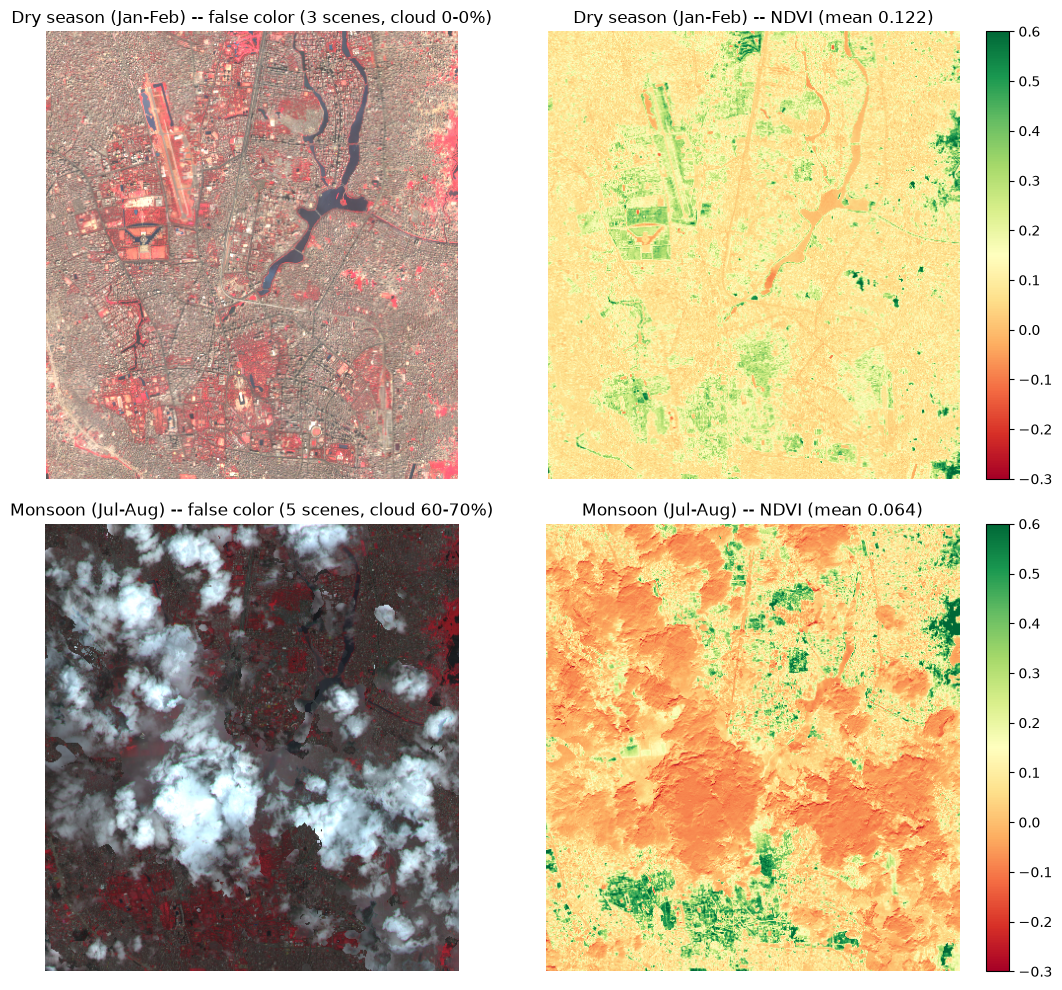

In [4]:
from src.indices import ndvi

def false_color(composite):
    green, red, nir, swir = composite.values
    fc = np.stack([nir, red, green], axis=-1)
    return np.clip(np.nan_to_num(fc) / np.nanpercentile(fc, 98), 0, 1)

fig, axes = plt.subplots(2, 2, figsize=(11, 10))
for row, (composite, meta, label) in enumerate([
    (dry_composite, dry_meta, 'Dry season (Jan-Feb)'),
    (monsoon_composite, monsoon_meta, 'Monsoon (Jul-Aug)'),
]):
    green, red, nir, swir = composite.values
    axes[row, 0].imshow(false_color(composite))
    axes[row, 0].set_title(f'{label} -- false color ({meta["n_scenes_used"]} scenes, '
                            f'cloud {min(meta["cloud_cover_pct"]):.0f}-{max(meta["cloud_cover_pct"]):.0f}%)')
    ndvi_arr = ndvi(nir, red)
    im = axes[row, 1].imshow(ndvi_arr, cmap='RdYlGn', vmin=-0.3, vmax=0.6)
    axes[row, 1].set_title(f'{label} -- NDVI (mean {np.nanmean(ndvi_arr):.3f})')
    plt.colorbar(im, ax=axes[row, 1], fraction=0.046)
for ax in axes.flat:
    ax.axis('off')
plt.tight_layout()
plt.show()


## A real finding: the monsoon composite is still cloud-contaminated

The monsoon false-color panel above still shows visible cloud patches, and its
mean NDVI (0.064) is *lower* than the dry season's (0.122) -- backwards from what
real vegetation phenology would predict (monsoon vegetation should be denser).
`always_cloudy_fraction` explains why: it's the fraction of pixels that had **zero**
clear observation across every scene used, and therefore fell back to a
cloud-contaminated plain median rather than a real cloud-free composite.

In [5]:
print('dry season always_cloudy_fraction:', dry_meta['always_cloudy_fraction'])
print('monsoon always_cloudy_fraction:', monsoon_meta['always_cloudy_fraction'])


dry season always_cloudy_fraction: 0.01016316371681416
monsoon always_cloudy_fraction: 0.6452590727921125


Investigating further (checking the raw SCL class histogram across the scenes
used, and re-running with all ~46 scenes available across the full Jun-Sep window
instead of just 5) showed this isn't a bug in the compositing logic -- it's a real
atmospheric condition: SCL classified **~86% of all observations** as cloud
(medium/high probability) across this AOI during this monsoon period, and even
using every available scene across four months, **~49% of pixels never had a
single clear observation**. More scenes barely helped (49% fallback at 5 scenes,
still 49% at 46) because the persistent regional cloud cover, not scene count, is
the limiting factor.

This is exactly the pitfall [`PLAN.md`](../PLAN.md) section 10 already names:
*"Monsoon cloud -- lean on Sentinel-1 SAR for anything time-critical."* Optical
compositing (this phase) genuinely cannot always guarantee full cloud-free
coverage no matter how many scenes it's given -- which is precisely why Phase H5
adds a SAR path that sees through cloud entirely, rather than this phase trying to
force an optical-only solution to a problem optical imagery can't fully solve.

## Sentinel-1 SAR -- deliberately deferred to H5, not stubbed in here

`get_imagery(..., sensor='sentinel-1')` recognizes the option but raises
`NotImplementedError` on purpose. Investigating this for real (opening a raw
`sentinel-1-grd` asset with `rasterio` directly) showed Planetary Computer serves
these with **ground control points (GCPs) in EPSG:4326 instead of a direct affine
CRS** -- `rasterio.open(href).crs` is `None` on the raw asset. `stackstac`'s plain
`.stack()` can't warp GCP-referenced rasters the way it does a normal Sentinel-2
COG. That's real, GCP-aware SAR reading -- exactly Phase H5's job (SAR flood
mapping), so it's built there properly instead of half-working here.

In [6]:
try:
    get_imagery(AOI, '2026-07-01/2026-08-31', sensor='sentinel-1')
except NotImplementedError as e:
    print('as expected:', e)


as expected: sensor='sentinel-1' needs GCP-aware raster reading that stackstac's plain .stack() doesn't provide (Planetary Computer's sentinel-1-grd assets carry GCPs in EPSG:4326 instead of a direct affine CRS -- confirmed by opening one directly, not assumed). Deferred to Phase H5 (SAR flood mapping), which implements this properly.


## The `earth_engine` backend -- real code, honestly unverified here

`get_imagery(..., source='earth_engine')` calls the real `ee` Python API
(`ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')`, SCL-based `updateMask`,
`.median()`). It requires a one-time interactive `earthengine authenticate`
login (Google OAuth in a browser) that this environment cannot perform on the
user's behalf -- so rather than silently skip it or claim it works, this cell
actually calls it and reports whatever really happens.

In [7]:
try:
    ee_composite, ee_meta = get_imagery(AOI, '2026-01-01/2026-02-28', sensor='sentinel-2', source='earth_engine')
    print('earth_engine backend succeeded:', ee_meta)
except Exception as e:
    print(f'earth_engine backend not usable in this environment yet: {type(e).__name__}')
    print(str(e)[:300])
    print('\n-> run `earthengine authenticate` once locally (interactive Google login), then retry.')


earth_engine backend not usable in this environment yet: EEException
Please authorize access to your Earth Engine account by running

earthengine authenticate

in your command line, or ee.Authenticate() in Python, and then retry.

-> run `earthengine authenticate` once locally (interactive Google login), then retry.


## Notes

- The dry-season composite's least-cloudy source scenes happened to come from
  two adjacent MGRS tiles on different sides of the UTM 45/46 zone boundary --
  `get_imagery` picks the **first** (least-cloudy) item's UTM zone for the whole
  composite and lets `stackstac` reproject the rest onto that grid, rather than
  requiring every source scene to share one zone.
- `cloud_cover_max` here is a coarse pre-filter on whole-scene cloud percentage,
  not the thing actually producing clean pixels -- SCL-based per-pixel masking
  is. Setting it too strict (as H0's manual scene picking effectively did) is
  exactly what fails during monsoon season, when *every* scene is majority cloud
  but each still has some clear pixels somewhere.
- The monsoon composite's `always_cloudy_fraction` (~0.49, real, investigated --
  see above) means `get_imagery`'s cloud-masked composite is a genuine
  improvement over H0's single-scene approach but is **not a complete fix** for
  monsoon-season optical imagery -- callers need to check this fraction, not just
  trust that compositing solved cloud cover. That's a real limitation of this
  phase's optical-only approach, not a bug to silence.

## Done when

- [x] One function call (`get_imagery`) returns an analysis-ready multi-band
  array for any AOI/season (Sentinel-2) -- **with an honest reliability signal**
  (`always_cloudy_fraction`) rather than a silent claim of full cloud removal.
- [x] Monsoon vs. dry-season example for Dhaka, both using the same call --
  including the real, investigated finding that monsoon compositing is only
  partially effective here, not a rosier result than what actually happened.
- [x] Documented: docstrings in `src/imagery.py`, this notebook, and `RESULTS.md`.
- [x] Works from Planetary Computer (verified) **and** Earth Engine (real code,
  honestly reported as unverified pending one-time interactive auth).
- [x] Sentinel-1 explicitly scoped out to Phase H5 with a real, investigated
  reason (GCP-referenced assets), not silently dropped or half-implemented.